In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
df=pd.read_csv("Enter your dataset path")

In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [ ]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


Now ,here we get an overview that there are some null values present in the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
df.isnull().sum().sort_values(ascending=False)

,0
glucose,388
education,105
BPMeds,53
totChol,50
cigsPerDay,29
BMI,19
heartRate,1
male,0
prevalentHyp,0
prevalentStroke,0


In [6]:
df.dtypes

,0
male,int64
age,int64
education,float64
currentSmoker,int64
cigsPerDay,float64
BPMeds,float64
prevalentStroke,int64
prevalentHyp,int64
diabetes,int64
totChol,float64


So all attributes we have are numeric ,so we can replace null values with mean,median or mode.Lets use median

In [7]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [8]:
null_replace=df[['glucose','education','BPMeds','totChol','cigsPerDay','BMI', 'heartRate']]
null_replace.head()

,glucose,education,BPMeds,totChol,cigsPerDay,BMI,heartRate
0,77.0,4.0,0.0,195.0,0.0,26.97,80.0
1,76.0,2.0,0.0,250.0,0.0,28.73,95.0
2,70.0,1.0,0.0,245.0,20.0,25.34,75.0
3,103.0,3.0,0.0,225.0,30.0,28.58,65.0
4,85.0,3.0,0.0,285.0,23.0,23.10,85.0


In [9]:
for column in null_replace:
  df[column].fillna(df[column].median(),inplace=True)

/tmp/ipython-input-453950734.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(),inplace=True)


In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


Now we dont have any null values .So we are ready to go for **EDA**

Chart for male


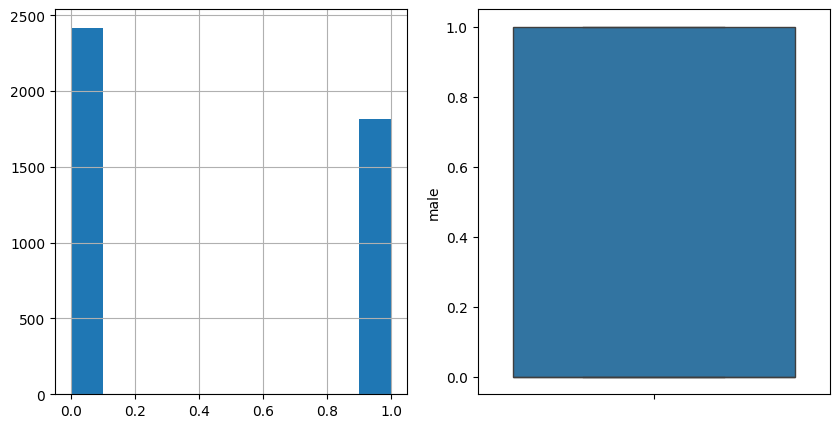

Chart for age


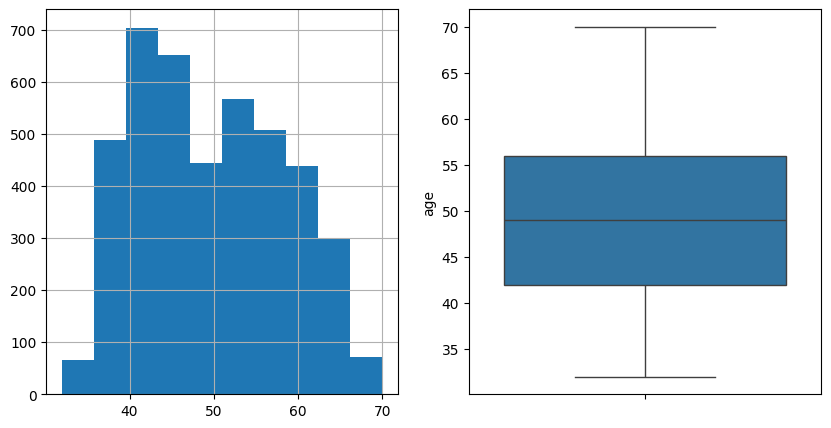

Chart for education


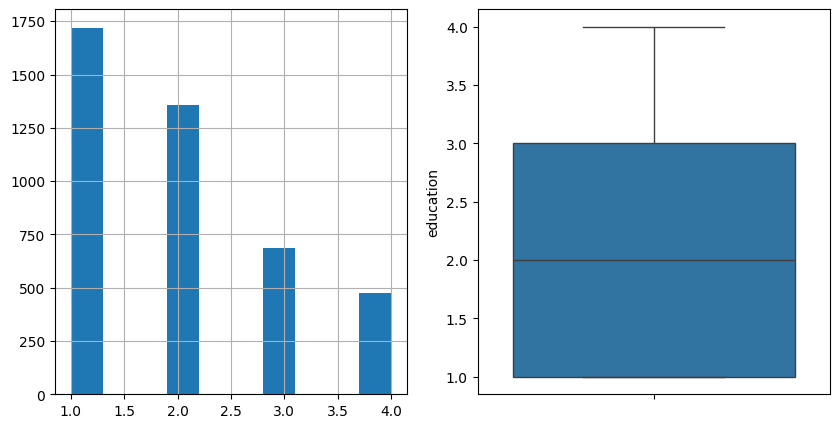

Chart for currentSmoker


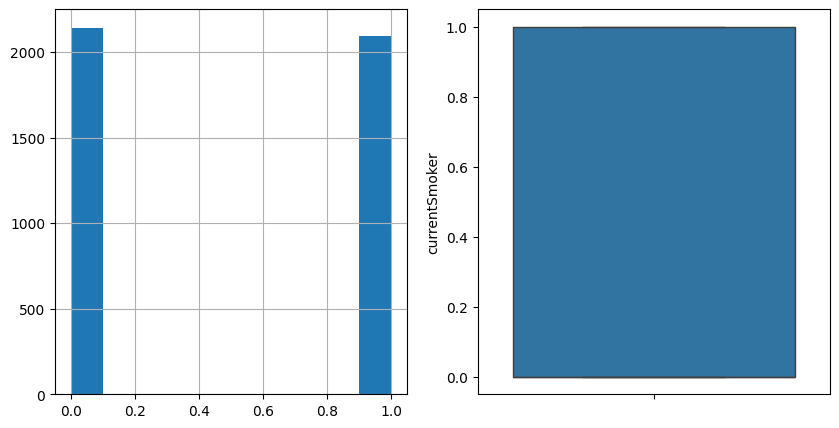

Chart for cigsPerDay


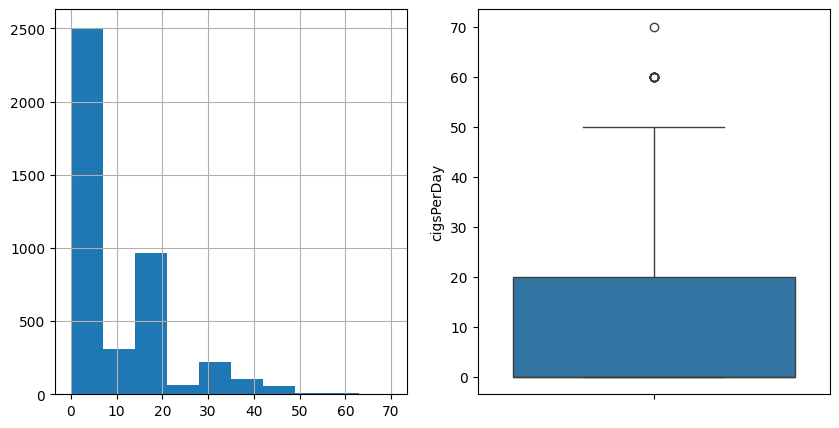

Chart for BPMeds


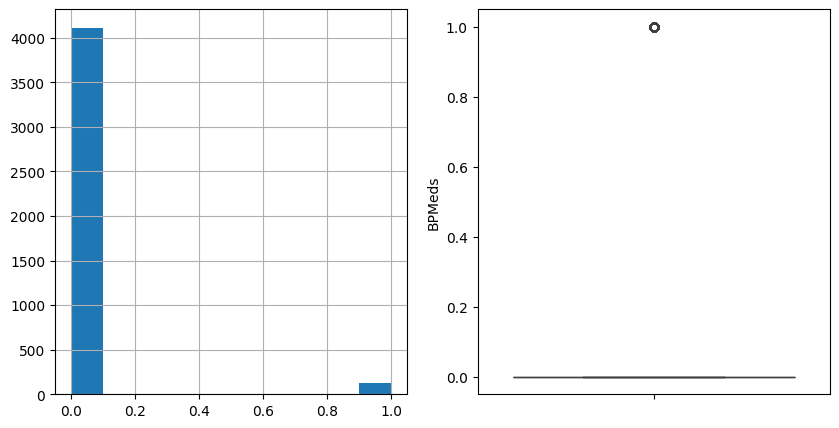

Chart for prevalentStroke


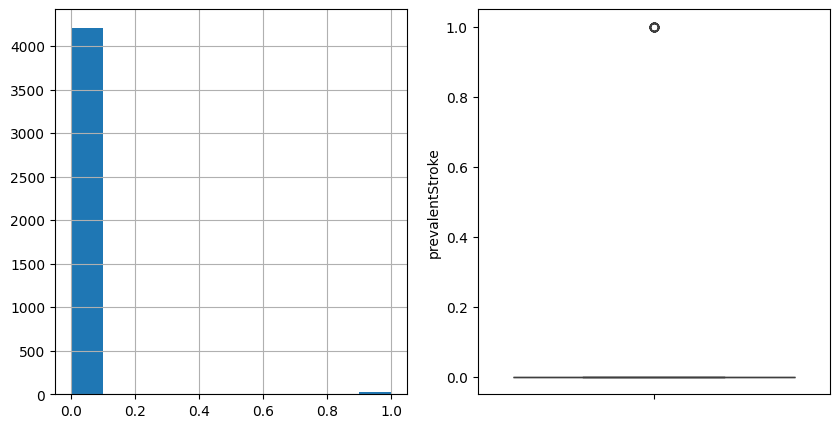

Chart for prevalentHyp


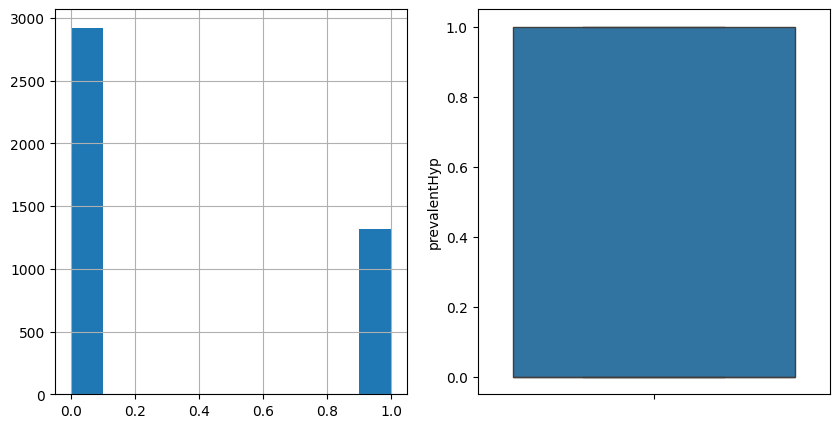

Chart for diabetes


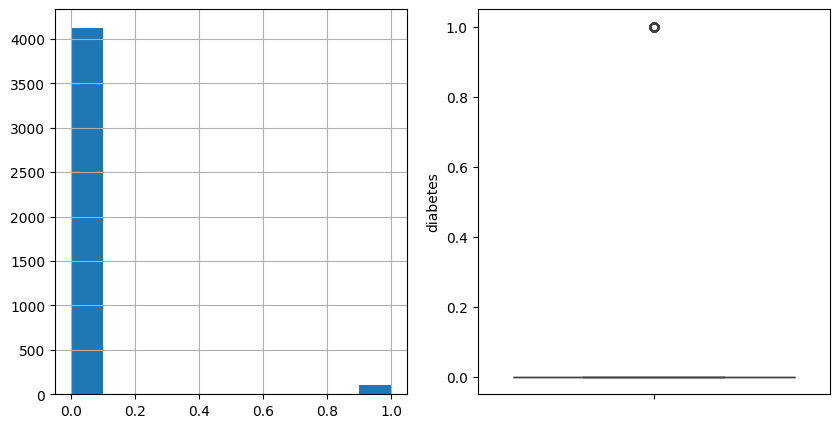

Chart for totChol


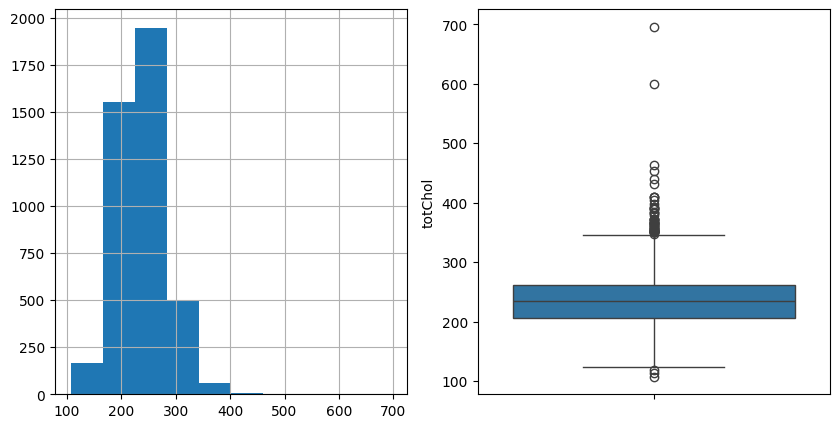

Chart for sysBP


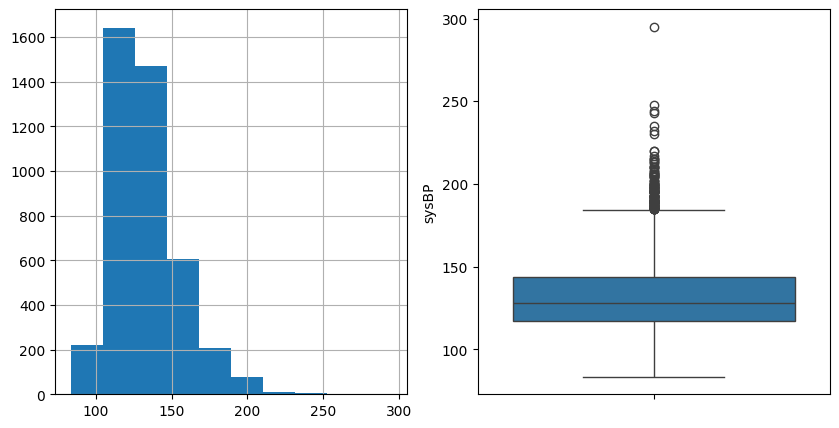

Chart for diaBP


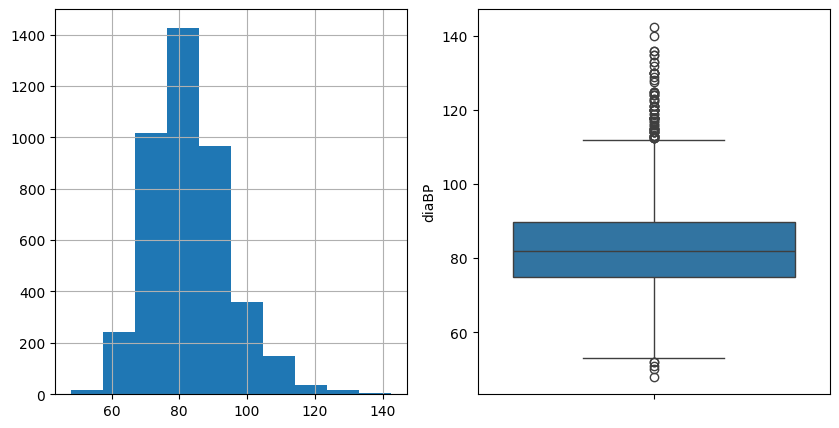

Chart for BMI


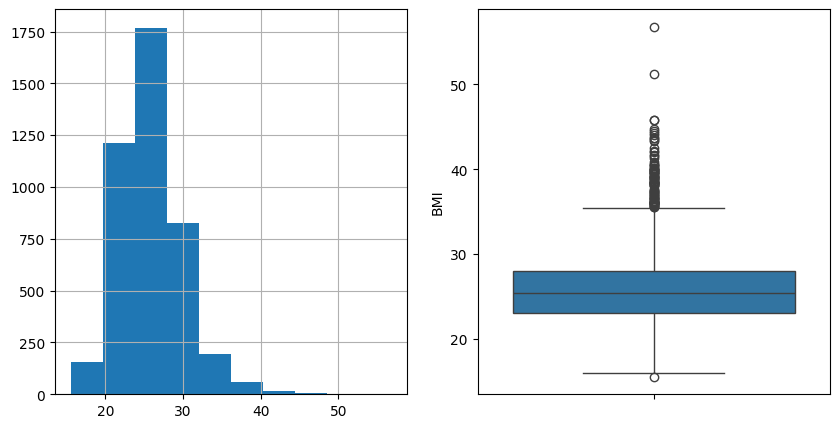

Chart for heartRate


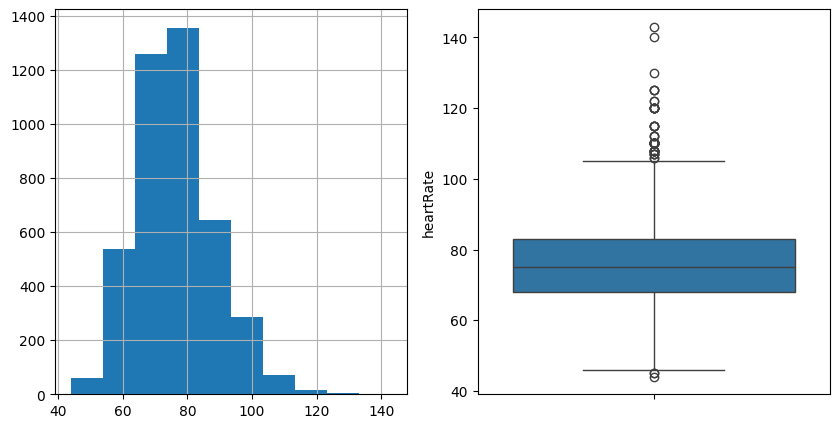

Chart for glucose


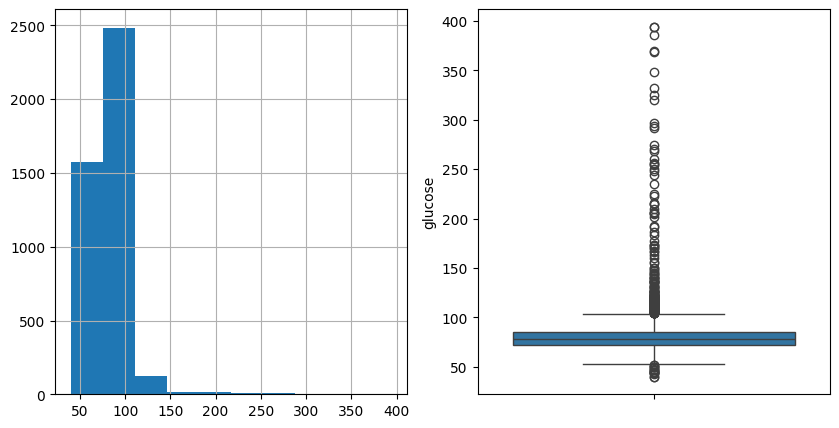

Chart for TenYearCHD


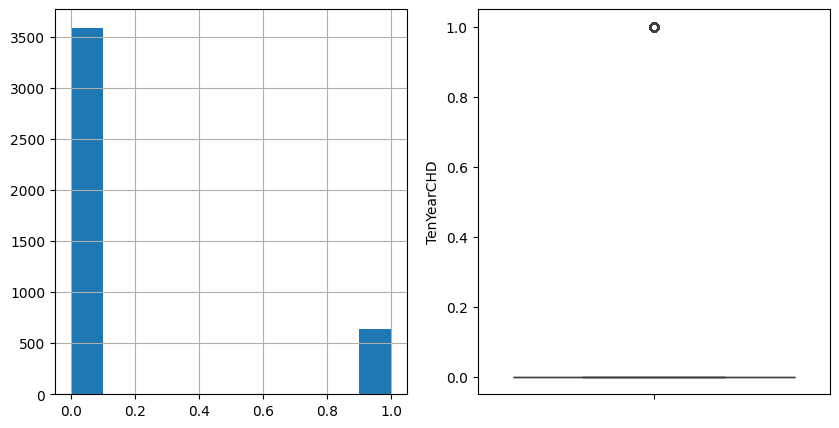

In [11]:
for column in df:
  plt.figure(figsize=(10,5))
  print(f"Chart for {column}")
  plt.subplot(1,2,1)
  df[column].hist()
  plt.subplot(1,2,2)

  sns.boxplot(df[column])
  plt.show()

Lets check correlation between Variables for feature engineering

In [12]:
df.corr()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.028979,0.017205,0.197596,0.315630,-0.051545,-0.004546,0.005313,0.015708,-0.069549,-0.035989,0.057933,0.081653,-0.116621,0.010073,0.088428
age,-0.028979,1.000000,-0.163547,-0.213748,-0.191847,0.120955,0.057655,0.307194,0.101258,0.260105,0.394302,0.206104,0.135174,-0.012848,0.117788,0.225256
education,0.017205,-0.163547,1.000000,0.018273,0.007618,-0.010365,-0.035150,-0.081021,-0.038136,-0.022364,-0.128273,-0.061719,-0.135501,-0.053683,-0.033982,-0.053383
currentSmoker,0.197596,-0.213748,0.018273,1.000000,0.760239,-0.048358,-0.032988,-0.103260,-0.044295,-0.046466,-0.130230,-0.107746,-0.167161,0.062330,-0.055177,0.019456
cigsPerDay,0.315630,-0.191847,0.007618,0.760239,1.000000,-0.044675,-0.032244,-0.065046,-0.036150,-0.026976,-0.088375,-0.056687,-0.092211,0.073853,-0.056863,0.058859
BPMeds,-0.051545,0.120955,-0.010365,-0.048358,-0.044675,1.000000,0.114609,0.258697,0.051394,0.078578,0.251503,0.192356,0.099584,0.015142,0.049124,0.086417
prevalentStroke,-0.004546,0.057655,-0.035150,-0.032988,-0.032244,0.114609,1.000000,0.074830,0.006949,0.000123,0.057009,0.045190,0.024265,-0.017674,0.018722,0.061810
prevalentHyp,0.005313,0.307194,-0.081021,-0.103260,-0.065046,0.258697,0.074830,1.000000,0.077808,0.163054,0.696755,0.615751,0.300510,0.147196,0.083571,0.177603
diabetes,0.015708,0.101258,-0.038136,-0.044295,-0.036150,0.051394,0.006949,0.077808,1.000000,0.040117,0.111283,0.050329,0.086025,0.048996,0.606493,0.097317
totChol,-0.069549,0.260105,-0.022364,-0.046466,-0.026976,0.078578,0.000123,0.163054,0.040117,1.000000,0.207522,0.163888,0.114811,0.090537,0.045559,0.081566


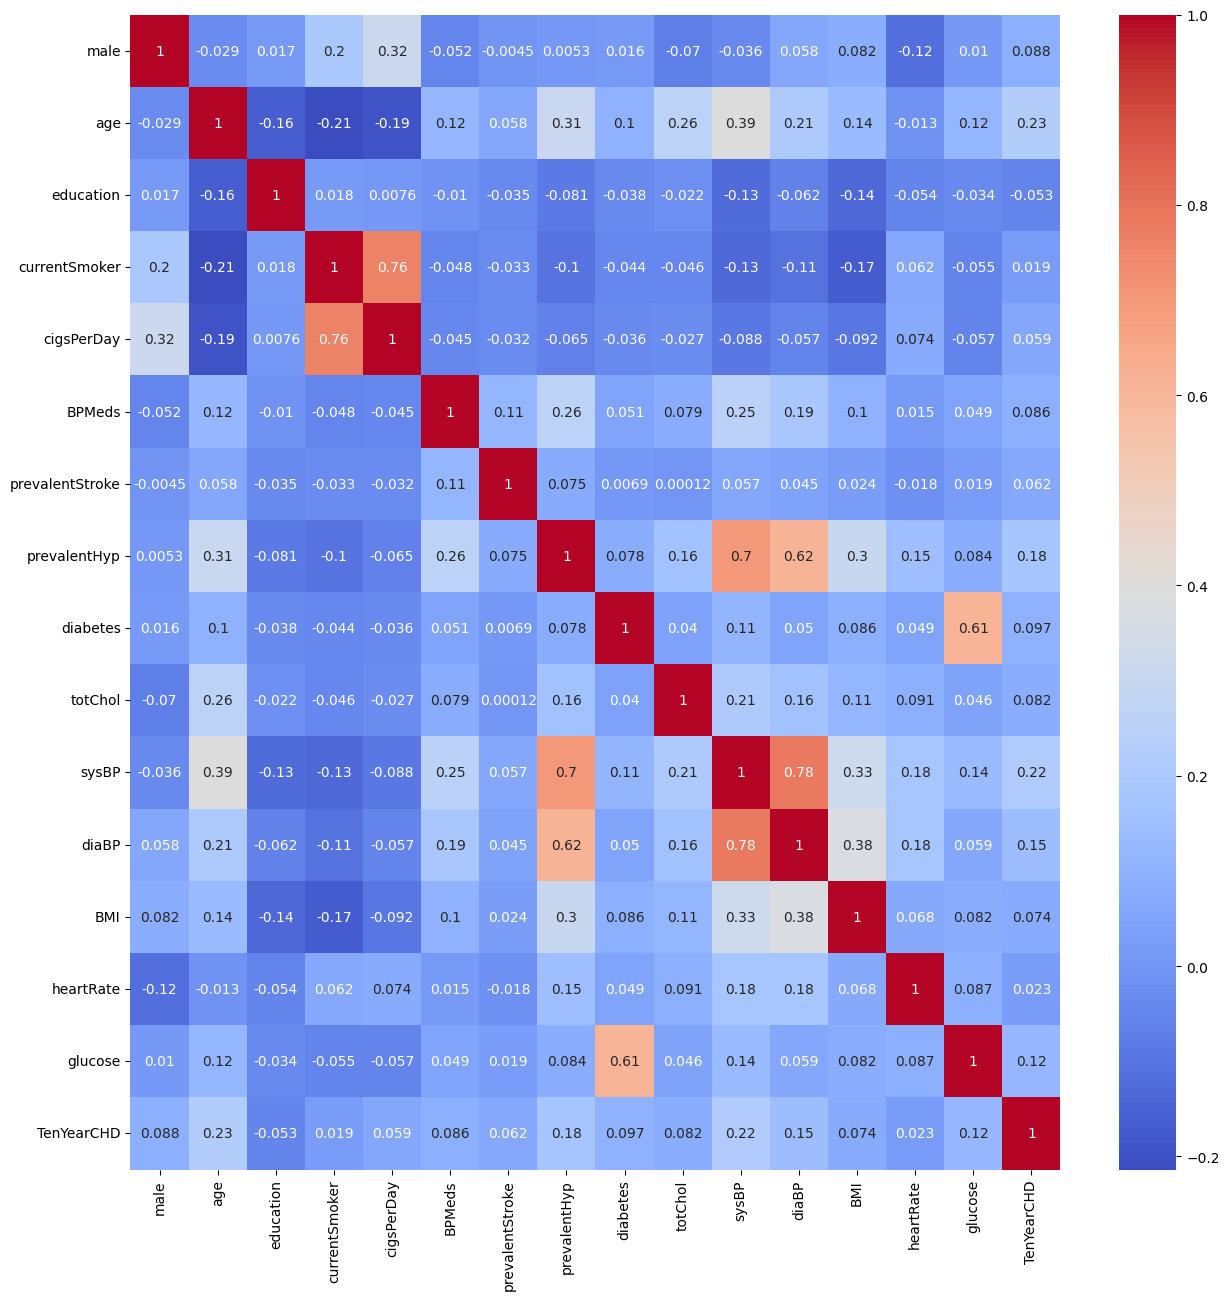

In [ ]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.show()

In [ ]:
for column in df:
  print(f"Correlation between TenYearCHD & {column} is {df['TenYearCHD'].corr(df[column])}")

Correlation between TenYearCHD & male is 0.08842756735157495
Correlation between TenYearCHD & age is 0.22525610383059036
Correlation between TenYearCHD & education is -0.05338264218805451
Correlation between TenYearCHD & currentSmoker is 0.01945626628489986
Correlation between TenYearCHD & cigsPerDay is 0.058859140542081426
Correlation between TenYearCHD & BPMeds is 0.08641713937851375
Correlation between TenYearCHD & prevalentStroke is 0.061809946077912604
Correlation between TenYearCHD & prevalentHyp is 0.17760273095315537
Correlation between TenYearCHD & diabetes is 0.0973165133747957
Correlation between TenYearCHD & totChol is 0.08156571583965133
Correlation between TenYearCHD & sysBP is 0.2164290392577289
Correlation between TenYearCHD & diaBP is 0.1452991039980636
Correlation between TenYearCHD & BMI is 0.07421661927315637
Correlation between TenYearCHD & heartRate is 0.022856756465716402
Correlation between TenYearCHD & glucose is 0.12127739554722289
Correlation between TenYearC

Now lets build the Model

In [16]:
from sklearn.linear_model import LogisticRegression
log1=LogisticRegression()


In [13]:
from sklearn.model_selection import train_test_split
x=df.drop('TenYearCHD',axis=1)
y=df['TenYearCHD']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape)

(3390, 15) (848, 15)


In [14]:
x.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose'],
      dtype='object')

In [17]:
log1.fit(x_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [18]:
yhat=log1.predict(x_test)
yhat[0:5]

array([0, 0, 0, 0, 0])

In [19]:
log1.score(x_test,y_test)

0.8549528301886793

Its good ,lets check other stats too

In [20]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,yhat))
print('\n')
print(classification_report(y_test,yhat))

[[720   4]
 [119   5]]


              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.56      0.04      0.08       124

    accuracy                           0.85       848
   macro avg       0.71      0.52      0.50       848
weighted avg       0.81      0.85      0.80       848



lets check cross validation score for this

In [ ]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(log1,x,y,cv=10)


In [22]:
cross_val_score1=score.mean()
cross_val_score1

np.float64(0.8496938980329185)

What if we put some high C value ,will it affect accuracy of model

In [23]:

log2=LogisticRegression(C=10,penalty='l2',solver='liblinear',max_iter=100)
log2.fit(x_train,y_train)

LogisticRegression(C=10, solver='liblinear')

In [24]:
yhat_prob2=log2.predict_proba(x_test)
yhat_prob2[0:5]

array([[0.66391837, 0.33608163],
       [0.92271616, 0.07728384],
       [0.90422496, 0.09577504],
       [0.83156143, 0.16843857],
       [0.93857647, 0.06142353]])

In [25]:
yhat2=log2.predict(x_test)
yhat2[0:5]

array([0, 0, 0, 0, 0])

In [26]:
log2.score(x_test,y_test)

0.8573113207547169

Here we can see we have bit increased the r2 score

In [27]:
print(f"Confusion Matrix : {confusion_matrix(y_test,yhat2)}")
print('\n')
print(f"Classification Report : {classification_report(y_test,yhat2)}")

Confusion Matrix : [[718   6]
 [115   9]]


Classification Report :               precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.60      0.07      0.13       124

    accuracy                           0.86       848
   macro avg       0.73      0.53      0.53       848
weighted avg       0.82      0.86      0.81       848



In [28]:
from sklearn.model_selection import cross_val_score
score2=cross_val_score(log2,x,y,cv=10)

In [29]:
mean_cross_val_score2=score2.mean()
mean_cross_val_score2

np.float64(0.8546478433471609)

In [30]:
print(cross_val_score1)
print(mean_cross_val_score2)

0.8496938980329185
0.8546478433471609


Here we can see we have improved the model . Now we can use it for predictions

In [31]:
x_train[0:2]

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
3252,1,40,4.0,1,30.0,0.0,0,0,0,205.0,131.0,81.0,23.74,66.0,87.0
3946,0,57,2.0,0,0.0,0.0,0,1,0,250.0,152.5,92.5,32.31,75.0,94.0


In [32]:
log2.predict([[1,40,4.0,1,30.0,0.0,0,0,0,205.0,131.0,81.0,23.74,66.0,87.0]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

Here We get a correct prediction,Now this model can be used for further applications

**Lets see whether we can find a better model or not .**

In [37]:
import pickle

# Assuming your trained model is called 'model'
filename = 'heart_disease_model.pkl'
pickle.dump(log2, open(filename, 'wb'))

print("✅ Model saved as 'heart_disease_model.pkl'")


✅ Model saved as 'heart_disease_model.pkl'
